### Code funzionante

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from random import randrange
import random

In [2]:
bits = 64

In [3]:
b = 23323323223

LUT_BITS = 8
LUT_SIZE = 1 << LUT_BITS          # 256

# ── Unified LUT ───────────────────────────────────────────────────────────────
# After an even-shift normalisation, b_norm ∈ [2^(bits-1), 2^(bits+1)).
# We tile that whole range with (LUT_BITS+1) index bits:
#
#   b_norm_at[i] = (LUT_SIZE + i) << (bits - LUT_BITS - 1),  i ∈ [0, 3·LUT_SIZE)
#
#   lo window  b_norm ∈ [2^(bits-1), 2^bits)   →  i ∈ [0,        LUT_SIZE)
#   hi window  b_norm ∈ [2^bits,     2^(bits+1))→  i ∈ [LUT_SIZE, 3·LUT_SIZE)
#
# lut[i] ≈ 2^(2·bits) / √(b_norm_at[i]), exact via isqrt (no float rounding).

scale4 = 1 << (4 * bits)
lut = [
    math.isqrt(scale4 // ((LUT_SIZE + i) << (bits - LUT_BITS - 1)))
    for i in range(3 * LUT_SIZE)
]

# ── Normalise with an even shift — branch-free ───────────────────────────────
# sqrt(b · 4^s) = sqrt(b) · 2^s, so keeping s even lets us recover sqrt(b)
# with a plain integer right-shift.  s & 1 is 1 iff s is odd → no branch.

s = bits - b.bit_length()
s += s & 1          # round up to even — branch-free
b_norm = b << s     # b < 2^bits, so s ≥ 0 here

# ── LUT seed — branch-free ───────────────────────────────────────────────────
# Extract (LUT_BITS+1) mantissa bits and subtract the base offset LUT_SIZE.
idx = (b_norm >> (bits - LUT_BITS - 1)) - LUT_SIZE   # ∈ [0, 3·LUT_SIZE)
x   = lut[idx]

# ── Newton-Raphson: refine 1/√b_norm ─────────────────────────────────────────
# x  ≈  (1/√b_norm) · 2^P,   P = 2·bits
# Step:  t  = b_norm · x² / 2^P          (→ 2^P at convergence)
#        x  ← x · (3·2^P − t) >> (P+1)
P = 2 * bits
for _ in range(2):
    t = (b_norm * x * x) >> P
    x = (x * (3 * (1 << P) - t)) >> (P + 1)

# ── Recover √b ───────────────────────────────────────────────────────────────
# b_norm = b · 2^s  →  √b = √b_norm / 2^(s/2) = b · x / 2^(P − s/2)
result = (b * x) >> (P - s // 2)

print("B     :", b)
print("My res:", result)
print("Expect:", math.isqrt(b))

B     : 23323323223
My res: 152719
Expect: 152719


### Todo: map the LUT as a polynomial

In [4]:
def get_bit(n, i):
    return (n >> i) & 1

In [5]:
def polylut(bit = 0):
    N = LUT_SIZE
    seq = np.array([get_bit(lut[i], bit) for i in range(N)], dtype=float)
    c = np.fft.fft(seq)  

    def f(x):
        s = 0.0
        for k in range(N):
            ang = 2 * math.pi * k * x / N
            s += c[k].real * math.cos(ang) - c[k].imag * math.sin(ang)
        return s / N

    return f

In [6]:
class Chebyshev:
    """
    Chebyshev(a, b, n, func)
    Given a function func, lower and upper limits of the interval [a,b],
    and maximum degree n, this class computes a Chebyshev approximation
    of the function.
    Method eval(x) yields the approximated function value.
    """
    def __init__(self, a, b, n, func):
        n = n + 1
        self.a = a
        self.b = b
        self.func = func

        bma = 0.5 * (b - a)
        bpa = 0.5 * (b + a)
        f = [func(math.cos(math.pi * (k + 0.5) / n) * bma + bpa) for k in range(n)]
        self.roots = f

        self.x = [math.cos(math.pi * (k + 0.5) / n) * bma + bpa for k in range(n)]

        fac = 2.0 / n
        self.c = [fac * sum([f[k] * math.cos(math.pi * j * (k + 0.5) / n)
                  for k in range(n)]) for j in range(n)]

    def eval(self, x):
        a,b = self.a, self.b
        #assert(a <= x <= b)
        y = (2.0 * x - a - b) * (1.0 / (b - a))
        y2 = 2.0 * y
        (d, dd) = (self.c[-1], 0)             # Special case first step for efficiency
        for cj in self.c[-2:0:-1]:            # Clenshaw's recurrence
            (d, dd) = (y2 * d - dd + cj, d)
        return y * d - dd + 0.5 * self.c[0]   # Last step is different

In [7]:
polyluts = []

for bit in range(lut[0].bit_length()):
    f = polylut(bit)
    
    c = Chebyshev(0, LUT_SIZE, 851, f)
    
    polyluts.append(c)

1.926788539829971e-08

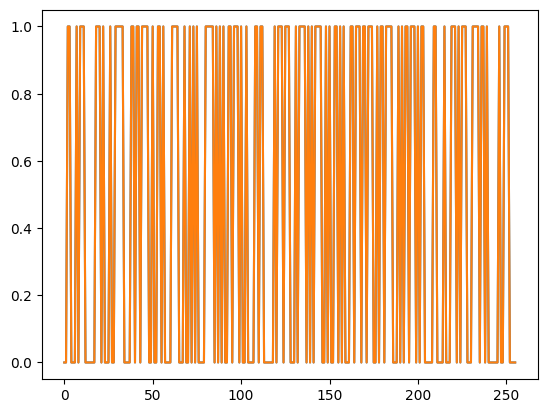

In [8]:
f = polylut(0)

c = Chebyshev(0, LUT_SIZE, 851, f)

x = np.arange(0, LUT_SIZE, 1)

y = np.vectorize(c.eval)(x)
plt.plot(x, y)

y_real = np.vectorize(f)(x)
plt.plot(x, y_real)


max(abs(y - y_real))

---

### Making the LUT polynomial

In [9]:
s = bits - b.bit_length()
b_norm = b << s

idx = (b_norm >> (bits - 1 - LUT_BITS)) & (LUT_SIZE - 1)

idx

91

In [10]:
binx = []

for i in range(bits * 2):
    if i >= len(polyluts):
        binx.append(0)
    else:
        binx.append(polyluts[i].eval(idx))

In [11]:
polydec = ([round(x) for x in list(binx)][::-1])

In [12]:
n = int("".join(map(str, polydec)), 2)

# We check that the polynomial LUT and the actual LUT are equal
n == lut[idx]

True

In [13]:
x = n

# Newton-Raphson — still 4 iterations, initial quality is identical
P = 2 * bits
for _ in range(2):
    t = (b_norm * x * x) >> P
    x = (x * (3 * (1 << P) - t)) >> (P + 1)

result = (b * x) >> (P - s // 2)

print("Result:", result)
print("Expect:", math.isqrt(b))


Result: 107989
Expect: 152719
